<a href="https://colab.research.google.com/github/MauricioLlugdar/CoffeeShop-Sales/blob/main/02_CoffeeShopSales_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Coffee Shop Sales (Dirty Dataset) - Modeling


**Introduction**: Using the two processed datasets (provided in CSV format from '01_CoffeeShopSales_Analysis_Exploration_Cleaning'), we will aim to predict sales for the following week. The first dataset, weekly_items_clean.csv, will be used to predict the sales volume for each individual item. The second, weekly_total_clean.csv, will be used to predict the total sales amount for the next week.

**Initial Stage**: We will establish a baseline to evaluate prediction accuracy and then compare it against various other models.

In [67]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge

In [36]:
REPO_NAME = "CoffeeShop-Sales"
REPO_URL = "https://github.com/MauricioLlugdar/CoffeeShop-Sales"

# Colab starts in /content, so we clone the repo if it is not already available
if not Path(f"/content/{REPO_NAME}").exists():
    !git clone {REPO_URL}

%cd /content/{REPO_NAME}

print("Working directory:", Path.cwd())

/content/CoffeeShop-Sales
Working directory: /content/CoffeeShop-Sales


In [37]:
df_weekly_total = pd.read_csv(
    "processed_data/weekly_total_clean.csv",
    parse_dates=["week"]
)

df_weekly_items = pd.read_csv(
    "processed_data/weekly_items_clean.csv",
    parse_dates=["week"]
)

Let's see the distribution of the data from df_weekly_total given the time in the axis 'x' an the "target_next_week_units" in the axis 'y'.

<Axes: xlabel='week', ylabel='target_next_week_units'>

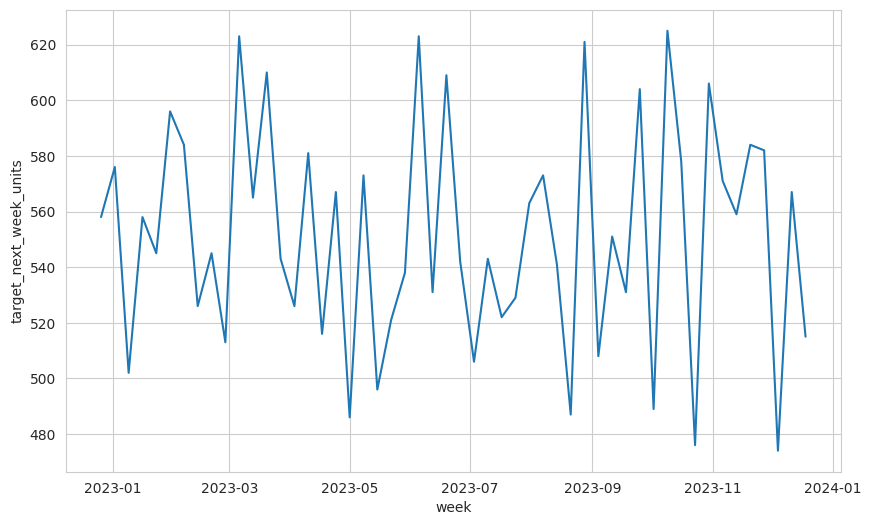

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_weekly_total, x="week", y="target_next_week_units")

Separe the training set from the test set

In [53]:
X_tot_train, X_tot_test, y_tot_train, y_tot_test = train_test_split(
    df_weekly_total.drop(columns=["week", "target_next_week_units"]),
    df_weekly_total["target_next_week_units"],
    test_size=0.25,
    random_state=12
)

Dummy Regressor MAE: 27.976331360946748


Function to evaluate the different models

In [65]:
def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "WAPE": wape
    }

Apply the dummyRegressor as a baseline and see the results

In [69]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_tot_train, y_tot_train)
y_pred_dummy = dummy.predict(X_tot_test)

evalDummy = evaluate_model("DummyRegressor", y_tot_test, y_pred_dummy)
print(evalDummy)

{'model': 'DummyRegressor', 'MAE': 27.976331360946748, 'RMSE': np.float64(34.01152297292113), 'R2': -0.11988706088426593, 'WAPE': np.float64(0.05154369440083727)}


And apply a temporal baseline one given the day before an another given the average of the last 4 weeks

In [74]:
y_pred_last_week = X_tot_test["units_sold"]

eval_last_week = evaluate_model(
    "Last Week Baseline",
    y_tot_test,
    y_pred_last_week
)

y_pred_last_four_weeks = X_tot_test["avg_last_4_weeks"]

eval_last_four_weeks = evaluate_model(
    "Last Four Weeks Baseline",
    y_tot_test,
    y_pred_last_four_weeks
)

print(eval_last_week)
print(eval_last_four_weeks)

{'model': 'Last Week Baseline', 'MAE': 54.61538461538461, 'RMSE': np.float64(65.13063795173512), 'R2': -3.1066976765501124, 'WAPE': np.float64(0.10062358276643991)}
{'model': 'Last Four Weeks Baseline', 'MAE': 25.46153846153846, 'RMSE': np.float64(37.0860485897325), 'R2': -0.3315062038861647, 'WAPE': np.float64(0.046910430839002266)}


Now apply linear regression models

In [70]:
linear_normalize = Pipeline([
    ("scaler", StandardScaler()),
    ("linear", LinearRegression())
])

linear_normalize.fit(X_tot_train, y_tot_train)
y_pred_linear_normalize = linear_normalize.predict(X_tot_test)

evalLinear = evaluate_model("LinearRegression", y_tot_test, y_pred_linear_normalize)
print(evalLinear)

{'model': 'LinearRegression', 'MAE': 25.33064398994586, 'RMSE': np.float64(29.72030182146988), 'R2': 0.1448771738192799, 'WAPE': np.float64(0.04666927038963948)}


In [71]:
ridge_normalized = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

ridge_normalized.fit(X_tot_train, y_tot_train)
y_pred_ridge_normalized = ridge_normalized.predict(X_tot_test)

evalRidge = evaluate_model("Ridge", y_tot_test, y_pred_ridge_normalized)
print(evalRidge)

{'model': 'Ridge', 'MAE': 24.72956462509876, 'RMSE': np.float64(30.27659103444592), 'R2': 0.11256609442315657, 'WAPE': np.float64(0.045561839587058374)}
